In [59]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.distributions import Normal
from stable_baselines3 import PPO

from stable_baselines3.common.vec_env import DummyVecEnv
from gym import Env, spaces
from sklearn.preprocessing import StandardScaler


In [60]:
df = pd.read_csv("../../data/narc_data/expanded_fertilizer_recommendations.csv", index_col=0 )

In [61]:
df.head()

,lon,ph,organic_matter,total_nitrogen,potassium,p2o5,boron,zinc,sand,clay,...,palika,crop,variety,UREA1,UREA2,UREA3,DAP,MOP,organic,boron_fert
lat,,,,,,,,,,,,,,,,,,,,,
27.65,83.837,6.37,2.69 %,0.12 %,187.76 kg/ha,66.41 kg/ha,1.05 ppm,1.76 ppm,48.71 %,14.92 %,...,Binayee tribeni Gaunpalika,Maize,OPV,1.55,2.90,2.90,3.47,2.23,10,1.5
27.65,83.837,6.37,2.69 %,0.12 %,187.76 kg/ha,66.41 kg/ha,1.05 ppm,1.76 ppm,48.71 %,14.92 %,...,Binayee tribeni Gaunpalika,Maize,Hybrid,2.50,3.62,3.62,2.89,3.34,10,1.5
27.65,83.837,6.37,2.69 %,0.12 %,187.76 kg/ha,66.41 kg/ha,1.05 ppm,1.76 ppm,48.71 %,14.92 %,...,Binayee tribeni Gaunpalika,Rice,OPV,2.50,3.62,3.62,2.89,3.34,6,1.0
27.65,83.837,6.37,2.69 %,0.12 %,187.76 kg/ha,66.41 kg/ha,1.05 ppm,1.76 ppm,48.71 %,14.92 %,...,Binayee tribeni Gaunpalika,Rice,Hybrid,2.50,3.62,3.62,2.89,3.34,6,1.0
27.65,83.837,6.37,2.69 %,0.12 %,187.76 kg/ha,66.41 kg/ha,1.05 ppm,1.76 ppm,48.71 %,14.92 %,...,Binayee tribeni Gaunpalika,Wheat,OPV,2.50,3.62,3.62,2.89,2.78,6,1.5


In [63]:
df['organic'].describe()

count    697415.000000
mean          7.600000
std           1.959593
min           6.000000
25%           6.000000
50%           6.000000
75%          10.000000
max          10.000000
Name: organic, dtype: float64

In [64]:
print(df['crop'].value_counts())


crop
Maize    278966
Rice     278966
Wheat    139483
Name: count, dtype: int64


In [65]:
df = df[df['crop'].str.lower() != 'maize'].reset_index(drop=True)


In [39]:
# import pandas as pd

# from sklearn.preprocessing import LabelEncoder
# #encoding categorical values
# encoder = LabelEncoder()
# df ['crop'] = encoder.fit_transform(df['crop'])
# df ['variety'] = encoder.fit_transform(df['variety'])
# df ['parentsoil'] = encoder.fit_transform(df['parentsoil'])



# # Convert the relevant columns to string type before applying str.replace
# df['ph'] = df['ph'].astype(str).str.replace('%', '', regex=False)
# df['organic_matter'] = df['organic_matter'].astype(str).str.replace('%', '', regex=False)
# df['total_nitrogen'] = df['total_nitrogen'].astype(str).str.replace('%', '', regex=False)

# # Remove 'ppm' from boron and zinc
# df['boron'] = df['boron'].astype(str).str.replace('ppm', '', regex=False)
# df['zinc'] = df['zinc'].astype(str).str.replace('ppm', '', regex=False)

# # Remove 'kg/ha' from potassium and p2o5
# df['potassium'] = df['potassium'].astype(str).str.replace('kg/ha', '', regex=False)
# df['p2o5'] = df['p2o5'].astype(str).str.replace('kg/ha', '', regex=False)

# # Remove '%' from sand, clay, and slit columns (if necessary)
# df['sand'] = df['sand'].astype(str).str.replace('%', '', regex=False)
# df['clay'] = df['clay'].astype(str).str.replace('%', '', regex=False)
# df['slit'] = df['slit'].astype(str).str.replace('%', '', regex=False)

# # Convert columns to appropriate numeric types (float or int)
# df['ph'] = df['ph'].astype(float)
# df['organic_matter'] = df['organic_matter'].astype(float)

# df['boron'] = df['boron'].astype(float)
# df['total_nitrogen'] = df['total_nitrogen'].astype(float)
# df['boron_fert'] = df['boron_fert'].astype(float)

# df['zinc'] = df['zinc'].astype(float)
# # df['zinc_fert'] = df['zinc_fert'].astype(float)
# df['organic'] = df['organic'].astype(float)

# df['potassium'] = df['potassium'].astype(float)
# df['p2o5'] = df['p2o5'].astype(float)
# df['sand'] = df['sand'].astype(float)
# df['clay'] = df['clay'].astype(float)
# df['slit'] = df['slit'].astype(float)
# df['UREA1'] = df['UREA1'].astype(float)


# df['UREA2'] = df['UREA2'].astype(float)

# df['UREA3'] = df['UREA3'].astype(float)

# df['DAP'] = df['DAP'].astype(float)
# df['MOP'] = df['MOP'].astype(float)
# df['parentsoil'] = df['parentsoil'].astype(float)
# df['variety'] = df['variety'].astype(float)
# df['crop'] = df['crop'].astype(float)


# # Now your columns are cleaned and converted to numeric types for further processing
# print(df.head())


In [66]:
# df.drop(columns='palika_num', inplace=True)
df.drop(columns='district', inplace=True)
df.drop(columns='province', inplace=True)
df.drop(columns='palika', inplace=True)




In [41]:
df.columns

Index(['lon', 'ph', 'organic_matter', 'total_nitrogen', 'potassium', 'p2o5',
       'boron', 'zinc', 'sand', 'clay', 'slit', 'parentsoil', 'crop',
       'variety', 'UREA1', 'UREA2', 'UREA3', 'DAP', 'MOP', 'organic',
       'boron_fert'],
      dtype='object')

In [42]:
df["p2o5"].describe()

count         418449
unique         16370
top       52.4 kg/ha
freq             162
Name: p2o5, dtype: object

In [43]:
df.columns

Index(['lon', 'ph', 'organic_matter', 'total_nitrogen', 'potassium', 'p2o5',
       'boron', 'zinc', 'sand', 'clay', 'slit', 'parentsoil', 'crop',
       'variety', 'UREA1', 'UREA2', 'UREA3', 'DAP', 'MOP', 'organic',
       'boron_fert'],
      dtype='object')

Good One

Using device: cuda
Train: (292903, 24)
Val:   (62778, 24)
Test:  (62768, 24)
Epoch 1/30 | Train=0.059708 | Val=0.027651
Epoch 2/30 | Train=0.025337 | Val=0.021058
Epoch 3/30 | Train=0.021291 | Val=0.019012
Epoch 4/30 | Train=0.019859 | Val=0.019542
Epoch 5/30 | Train=0.018694 | Val=0.019975
Epoch 6/30 | Train=0.017432 | Val=0.016062
Epoch 7/30 | Train=0.016340 | Val=0.015877
Epoch 8/30 | Train=0.016141 | Val=0.052710
Epoch 9/30 | Train=0.016102 | Val=0.011106
Epoch 10/30 | Train=0.015373 | Val=0.013096
Epoch 11/30 | Train=0.017199 | Val=0.016200
Epoch 12/30 | Train=0.018300 | Val=0.016014
Epoch 13/30 | Train=0.016534 | Val=0.025029
Epoch 14/30 | Train=0.016034 | Val=0.013327
Epoch 15/30 | Train=0.017636 | Val=0.012006
Epoch 16/30 | Train=0.016552 | Val=0.038798
Epoch 17/30 | Train=0.018432 | Val=0.024157
Epoch 18/30 | Train=0.020694 | Val=0.017187
Epoch 19/30 | Train=0.017891 | Val=0.028071
Epoch 20/30 | Train=0.016207 | Val=0.015956
Epoch 21/30 | Train=0.014372 | Val=0.010712
Epoch 22

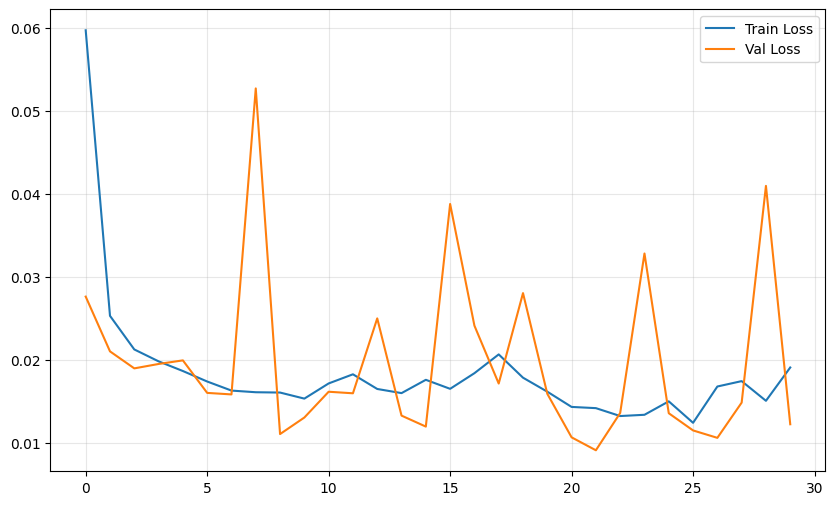


===== REAL TEST PERFORMANCE =====
MAE  : 0.0323
RMSE : 0.0791
R²   : 0.9905

===== Per-Fertilizer =====
UREA1: MAE=0.0250, RMSE=0.0480, R²=0.9959
DAP: MAE=0.0479, RMSE=0.1107, R²=0.9851
MOP: MAE=0.0241, RMSE=0.0648, R²=0.9905

Running MC Dropout (T=200)...
MC Dropout complete!
mean_np shape: (62768, 3)
std_np shape: (62768, 3)


In [67]:
# advanced_fertnet_v2.py
# Full clean version with Train / Validation / Test split.

# ============================================================
# Imports
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ============================================================
# 0. Reproducibility + device
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 1. CATEGORICAL ENCODING
# ============================================================
assert 'df' in globals(), "Load your dataset into variable `df`."

df = pd.get_dummies(
    df,
    columns=['crop', 'variety', 'parentsoil'],
    drop_first=True
)

# ============================================================
# 2. NUMERIC CLEANING
# ============================================================
num_cols = [
    'ph','organic_matter','total_nitrogen','potassium','p2o5',
    'zinc','sand','clay','slit','boron'
]

for col in num_cols:
    df[col] = (
        df[col].astype(str)
        .str.replace('%', '', regex=False)
        .str.replace('ppm', '', regex=False)
        .str.replace('kg/ha', '', regex=False)
        .astype(float)
    )

# ============================================================
# 3. FEATURES / TARGETS
# ============================================================
fert_cols = ['UREA1','DAP','MOP']
soil_cols = [c for c in df.columns if c not in fert_cols]

X_df = df[soil_cols].copy()
y_df = df[fert_cols].copy()

# Fertilizer bounds (for PPO / RL later)
fert_min = np.zeros(len(fert_cols))
fert_max = y_df.max(axis=0).values.astype(float)

# ============================================================
# 4. SCALING
# ============================================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_df)
y_scaled = scaler_y.fit_transform(y_df)

# ============================================================
# 5. TRUE Train / Validation / Test Split
# ============================================================
X_temp, X_test_np, y_temp, y_test_np = train_test_split(
    X_scaled, y_scaled, test_size=0.15, random_state=SEED
)

X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED
)

print("Train:", X_train_np.shape)
print("Val:  ", X_val_np.shape)
print("Test: ", X_test_np.shape)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_val   = torch.tensor(X_val_np, dtype=torch.float32)
y_val   = torch.tensor(y_val_np, dtype=torch.float32)
X_test  = torch.tensor(X_test_np, dtype=torch.float32)
y_test  = torch.tensor(y_test_np, dtype=torch.float32)

BATCH_SIZE = 256
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)

# ============================================================
# 3. Model components
# ============================================================
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, device=x.device)
        random_tensor.floor_()
        return x.div(keep_prob) * random_tensor

class SEBlock(nn.Module):
    def __init__(self, dim, reduction=4):
        super().__init__()
        hidden = max(1, dim // reduction)
        self.fc = nn.Sequential(
            nn.Linear(dim, hidden),
            Swish(),
            nn.Linear(hidden, dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(x)

class ResidualBlock(nn.Module):
    def __init__(self, dim, expansion=4, dropout=0.2, droppath=0.0):
        super().__init__()
        hidden = dim * expansion
        self.norm1 = nn.LayerNorm(dim)
        self.fc1   = nn.Linear(dim, hidden)
        self.act   = Swish()
        self.drop  = nn.Dropout(dropout)
        self.fc2   = nn.Linear(hidden, dim)
        self.se    = SEBlock(dim)
        self.dp    = DropPath(droppath)

    def forward(self, x):
        identity = x
        out = self.norm1(x)
        out = self.fc1(out)
        out = self.act(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.se(out)
        out = self.dp(out)
        return identity + out

class FertNetV2(nn.Module):
    def __init__(self, input_dim, output_dim, depth=6, hidden_dim=256, dropout=0.2, droppath_max=0.15):
        super().__init__()
        self.fc_in = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            ResidualBlock(hidden_dim, expansion=4, dropout=dropout,
                          droppath=(i/depth)*droppath_max)
            for i in range(depth)
        ])
        self.norm_out = nn.LayerNorm(hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc_in(x)
        for blk in self.layers:
            x = blk(x)
        x = self.norm_out(x)
        return self.fc_out(x)

model = FertNetV2(
    input_dim=X_train.shape[1],
    output_dim=y_train.shape[1]
).to(device)

# ============================================================
# 4. Training setup
# ============================================================
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

max_epochs = 30
patience = 40
best_val = float('inf')
wait = 0
best_state = None
train_loss_history = []
val_loss_history = []

# ============================================================
# 5. Training loop
# ============================================================
for epoch in range(1, max_epochs + 1):

    model.train()
    total_train = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_train += loss.item() * xb.size(0)

    train_loss = total_train / len(train_loader.dataset)
    train_loss_history.append(train_loss)

    model.eval()
    total_val = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            total_val += loss.item() * xb.size(0)

    val_loss = total_val / len(val_loader.dataset)
    val_loss_history.append(val_loss)

    scheduler.step()

    print(f"Epoch {epoch}/{max_epochs} | Train={train_loss:.6f} | Val={val_loss:.6f}")

    if val_loss < best_val - 1e-5:
        best_val = val_loss
        wait = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
    else:
        wait += 1

    if wait > patience:
        print(f"Stopped early at {epoch}, best at {best_epoch}")
        break

model.load_state_dict(best_state)
print(f"Loaded best model (epoch {best_epoch})")

os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/fertnetv2_best.pth")
print("Saved model -> models/fertnetv2_best.pth")

# ============================================================
# 6. Loss curves
# ============================================================
plt.figure(figsize=(10,6))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# 7. MC Dropout Uncertainty Function
# ============================================================
def predict_with_uncertainty(input_row, mc_runs=50):
    model.train()
    x_scaled = scaler_X.transform([input_row])
    xt = torch.tensor(x_scaled, dtype=torch.float32).to(device)

    preds = []
    with torch.no_grad():
        for _ in range(mc_runs):
            y_scaled = model(xt).cpu().numpy()
            y = scaler_y.inverse_transform(y_scaled)
            y = np.clip(y, fert_min, fert_max)
            preds.append(y.flatten())

    preds = np.array(preds)
    mean = preds.mean(axis=0)
    std  = preds.std(axis=0)
    pct  = (std / (mean + 1e-8)) * 100

    model.eval()
    return mean, std, pct

# ============================================================
# 8. Final Test Evaluation
# ============================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()
all_true = []
all_pred = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        yb  = yb.cpu().numpy()

        pred = scaler_y.inverse_transform(pred)
        true = scaler_y.inverse_transform(yb)

        all_pred.append(pred)
        all_true.append(true)

all_pred = np.vstack(all_pred)
all_true = np.vstack(all_true)

print("\n===== REAL TEST PERFORMANCE =====")
print(f"MAE  : {mean_absolute_error(all_true, all_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(all_true, all_pred)):.4f}")
print(f"R²   : {r2_score(all_true, all_pred):.4f}")

print("\n===== Per-Fertilizer =====")
for i, f in enumerate(fert_cols):
    mae  = mean_absolute_error(all_true[:,i], all_pred[:,i])
    rmse = np.sqrt(mean_squared_error(all_true[:,i], all_pred[:,i]))
    r2   = r2_score(all_true[:,i], all_pred[:,i])
    print(f"{f}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
# ============================================================
# 9. MC Dropout on FULL TEST SET
# ============================================================

def mc_dropout_full(model, X_tensor, scaler_y, T=200, device=device):
    """
    Compute MC Dropout uncertainty for the entire test set.
    model must have dropout active in train() mode.
    """
    model.train()   # enable dropout
    all_preds = []

    with torch.no_grad():
        for _ in range(T):
            # forward pass with dropout ON
            y_scaled = model(X_tensor.to(device)).cpu().numpy()   # (N, D)
            y = scaler_y.inverse_transform(y_scaled)              # (N, D)
            y = np.clip(y, fert_min, fert_max)
            all_preds.append(y)

    all_preds = np.stack(all_preds)   # (T, N, D)
    mean = all_preds.mean(axis=0)     # (N, D)
    std  = all_preds.std(axis=0)      # (N, D)

    model.eval()
    return mean, std, all_preds


# ---------- RUN MC DROPOUT ----------
print("\nRunning MC Dropout (T=200)...")
mean_np, std_np, all_preds = mc_dropout_full(
    model,
    X_test,
    scaler_y,
    T=200,
    device=device
)

print("MC Dropout complete!")
print("mean_np shape:", mean_np.shape)
print("std_np shape:", std_np.shape)



In [45]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Model expects input_dim:", model.fc_in.in_features)


X_train shape: torch.Size([292903, 23])
X_test shape: torch.Size([62768, 23])
Model expects input_dim: 23


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# Set device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

X_test = X_test.to(device)
y_test = y_test.to(device)

# =========================
#  TESTING SET EVALUATION
# =========================
model.eval()

with torch.no_grad():
    y_pred_scaled = model(X_test).cpu().numpy()   # move back to CPU

# Inverse scale predictions & ground truth
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test.cpu().numpy())

# Compute metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("\n===== TEST SET PERFORMANCE =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# Per-fertilizer metrics
print("\n===== PER-FERTILIZER RESULTS =====")
for i, fert in enumerate(fert_cols):
    fert_mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    fert_rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    fert_r2 = r2_score(y_true[:, i], y_pred[:, i])

    print(f"\n{fert}:")
    print(f"   MAE  = {fert_mae:.4f}")
    print(f"   RMSE = {fert_rmse:.4f}")
    print(f"   R²   = {fert_r2:.4f}")



===== TEST SET PERFORMANCE =====
MAE  : 0.0227
RMSE : 0.0684
R²   : 0.7430

===== PER-FERTILIZER RESULTS =====

UREA1:
   MAE  = 0.0243
   RMSE = 0.0492
   R²   = 0.9957

DAP:
   MAE  = 0.0435
   RMSE = 0.1120
   R²   = 0.9847

MOP:
   MAE  = 0.0228
   RMSE = 0.0614
   R²   = 0.9915

organic:
   MAE  = 0.0001
   RMSE = 0.0002
   R²   = 0.0000


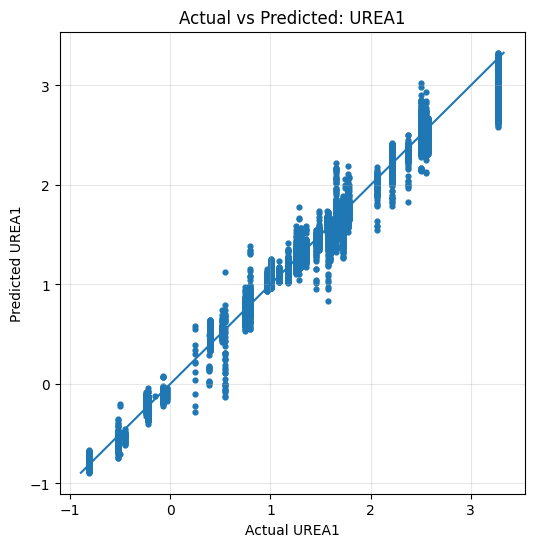

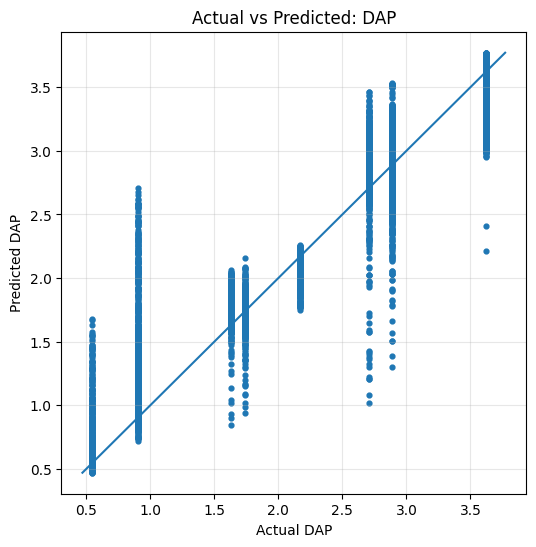

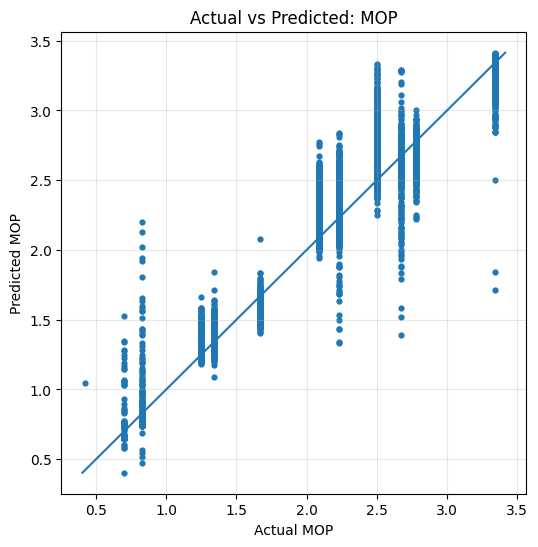

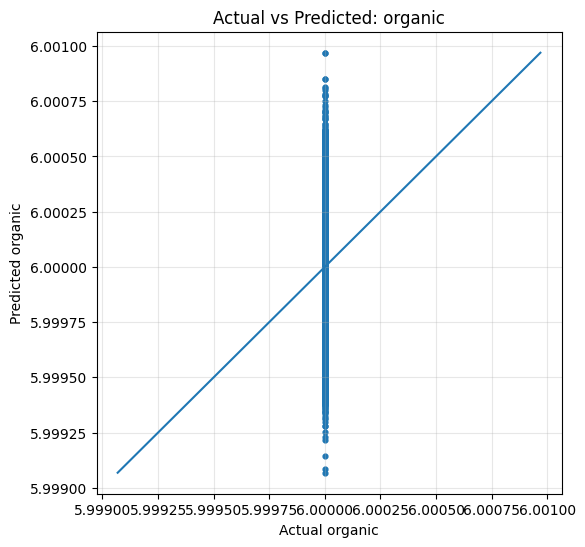

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Ensure model is in eval mode
model.eval()

# Generate predictions on test set
with torch.no_grad():
    y_pred_scaled = model(X_test).cpu().numpy()

# Inverse scale predictions & true values
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test.cpu().numpy())

# Plot separate scatter plots for each fertilizer
for i, fert in enumerate(fert_cols):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true[:, i], y_pred[:, i], s=12)
    plt.xlabel(f"Actual {fert}")
    plt.ylabel(f"Predicted {fert}")
    plt.title(f"Actual vs Predicted: {fert}")
    # 45-degree reference line
    min_val = min(y_true[:, i].min(), y_pred[:, i].min())
    max_val = max(y_true[:, i].max(), y_pred[:, i].max())
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.grid(True, alpha=0.3)
    plt.show()


A. Scalar metrics to report (add to MAE / RMSE / R²)

Median Absolute Error (MedAE) — robust to outliers.

MAPE or SMAPE — relative error (careful with zeros). Use SMAPE if zeros present.

Explained Variance — similar to R² but slightly different.

Pearson / Spearman correlation between true & predicted.

Per-group metrics (by crop, variety, pH bin) — shows where model fails.

In [48]:
from sklearn.metrics import median_absolute_error, explained_variance_score
import numpy as np
from scipy.stats import pearsonr, spearmanr

# y_true, y_pred are (N, n_ferts) numpy arrays
def safe_smape(y_true, y_pred, eps=1e-6):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.abs(y_pred - y_true) / (denom + eps)) * 100

for i, fert in enumerate(fert_cols):
    mae = mean_absolute_error(y_true[:,i], y_pred[:,i])
    medae = median_absolute_error(y_true[:,i], y_pred[:,i])
    ev = explained_variance_score(y_true[:,i], y_pred[:,i])
    pear, _ = pearsonr(y_true[:,i], y_pred[:,i])
    spear, _ = spearmanr(y_true[:,i], y_pred[:,i])
    smape = safe_smape(y_true[:,i], y_pred[:,i])
    print(f"{fert}: MAE={mae:.4f}, MedAE={medae:.4f}, EV={ev:.4f}, Pearson={pear:.4f}, Spearman={spear:.4f}, SMAPE={smape:.2f}%")


UREA1: MAE=0.0243, MedAE=0.0127, EV=0.9957, Pearson=0.9979, Spearman=0.9954, SMAPE=2.71%
DAP: MAE=0.0435, MedAE=0.0176, EV=0.9847, Pearson=0.9923, Spearman=0.9814, SMAPE=2.39%
MOP: MAE=0.0228, MedAE=0.0075, EV=0.9915, Pearson=0.9958, Spearman=0.9375, SMAPE=1.14%
organic: MAE=0.0001, MedAE=0.0001, EV=0.0000, Pearson=nan, Spearman=nan, SMAPE=0.00%


C:\Users\Acer\AppData\Local\Temp\ipykernel_25292\905288532.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pear, _ = pearsonr(y_true[:,i], y_pred[:,i])
C:\Users\Acer\AppData\Local\Temp\ipykernel_25292\905288532.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spear, _ = spearmanr(y_true[:,i], y_pred[:,i])


B. Uncertainty & prediction-interval checks (important since you use MC Dropout)

Compute prediction mean and std from MC runs (you already have this).

Build central prediction intervals (e.g., 90% CI = mean ± 1.645·std for approx normal).

Empirical coverage: what fraction of true values fall inside the nominal interval? Should be near nominal (e.g., 90%).

Calibration vs sharpness: scatter predicted std vs absolute error — a well-calibrated model has higher error where uncertainty is higher.

In [49]:
# =============================
# MC DROPOUT ON FULL TEST SET
# =============================

model.train()   # enable dropout
T = 200
     # number of Monte Carlo passes

all_preds = []

with torch.no_grad():
    for _ in range(T):
        y_scaled = model(X_test.to(device)).cpu().numpy()     # (3750, 5)
        y = scaler_y.inverse_transform(y_scaled)              # inverse scale
        y = np.clip(y, fert_min, fert_max)                    # clip
        all_preds.append(y)

all_preds = np.stack(all_preds)   # shape (50, 3750, 5)

# Final mean & std per sample
mean_np = all_preds.mean(axis=0)   # (3750, 5)
std_np  = all_preds.std(axis=0)    # (3750, 5)

print("mean:", mean_np.shape)
print("std:", std_np.shape)


mean: (62768, 4)
std: (62768, 4)


In [50]:
y_true_np = scaler_y.inverse_transform(y_test.cpu().numpy())  # (3750, 5)

z90 = 1.645
lower = mean_np - z90 * std_np    # (3750, 5)
upper = mean_np + z90 * std_np    # (3750, 5)

coverage = np.mean((y_true_np >= lower) & (y_true_np <= upper), axis=0)

print("\n90% CI empirical coverage per fertilizer:")
for fert, cov in zip(fert_cols, coverage):
    print(f"  {fert}: {cov:.3f}")



90% CI empirical coverage per fertilizer:
  UREA1: 0.846
  DAP: 0.787
  MOP: 0.911
  organic: 0.658


In [51]:
import torch
import joblib
import numpy as np
import os

# ==============================
# 0️⃣ Reproducibility
# ==============================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ==============================
# 1️⃣ Create folder if not exists
# ==============================
os.makedirs("models_fertnet", exist_ok=True)
os.makedirs("data", exist_ok=True)

# ==============================
# 2️⃣ Save FertNet model weights
# ==============================
torch.save(model.state_dict(), "models_fertnet/fertnet_best.pth")
print("✅ FertNet weights saved -> models_fertnet/fertnet_best.pth")

# ==============================
# 3️⃣ Save the scalers
# ==============================
joblib.dump(scaler_X, "models_fertnet/scaler_X.pkl")
joblib.dump(scaler_y, "models_fertnet/scaler_y.pkl")
print("✅ Scalers saved -> models_fertnet/scaler_X.pkl & scaler_y.pkl") 

# ==============================
# 4️⃣ Save metadata 
# ==============================
meta = {
    "fert_min": fert_min,
    "fert_max": fert_max,
    "soil_cols": soil_cols,
    "fert_cols": fert_cols,
    "seed": SEED
}
joblib.dump(meta, "models_fertnet/meta.pkl")
print("✅ Metadata saved -> models_fertnet/meta.pkl")

# ==============================
# 5️⃣ Save dataset (compressed)
# ==============================
np.savez_compressed("data/fertnet_data.npz",
                    X_train=X_train.cpu().numpy(),
                    y_train=y_train.cpu().numpy(),
                    X_val=X_val.cpu().numpy(),
                    y_val=y_val.cpu().numpy(),
                    X_test=X_test.cpu().numpy(),
                    y_test=y_test.cpu().numpy())
print("✅ Dataset saved -> data/fertnet_data.npz") 


✅ FertNet weights saved -> models_fertnet/fertnet_best.pth
✅ Scalers saved -> models_fertnet/scaler_X.pkl & scaler_y.pkl
✅ Metadata saved -> models_fertnet/meta.pkl
✅ Dataset saved -> data/fertnet_data.npz
